# Tutorial: Bayesian Statistics Lab: Priors, Model Selection, and Posterior Inference

Federico Cerutti <federico.cerutti@unibs.it>

The notes are released with CC0. The code is MIT.

**Format of this notebook.** This notebook is designed as a self-guided lab. The code cells are intentionally compact and should be treated as the validated reference implementation. The teaching material therefore lives in the markdown: read the text first, inspect the code second, and only then run the cell.



**Useful references for students who want a formal API reference**
- [PyMC documentation](https://www.pymc.io/projects/docs/en/stable/learn.html)
- [ArviZ documentation](https://python.arviz.org/en/stable/)
- [SciPy statistical tests](https://docs.scipy.org/doc/scipy/reference/stats.html)
- [statsmodels power analysis](https://www.statsmodels.org/stable/stats.html#power-and-sample-size)

**Main take-away for this lab**
- In the examples below, Bayesian analysis is more informative for decision making because it returns full uncertainty distributions and directly interpretable probabilities, not only a reject / fail-to-reject decision.


## 0. Environment setup and reading strategy


- The first code cell installs missing packages in a Colab-friendly way.
- The second code cell imports the libraries, fixes the global seed, and creates the random number generator used throughout the notebook.

As you read the import cell, classify the libraries by role:
- **classical statistics** (`scipy`, `statsmodels`),
- **Bayesian modeling and diagnostics** (`pymc`, `arviz`),
- **data handling and plotting** (`pandas`, `numpy`, `matplotlib`).


In [1]:
# Colab-friendly install cell.
# It only installs packages that are missing in the current runtime.
import subprocess
import sys

required = ["pymc", "arviz", "statsmodels"]
# ArviZ — works hand-in-hand with PyMC. After sampling, ArviZ gives you summaries (az.summary()), diagnostic plots, and model comparison (az.compare() with LOO). Think of it as the "results viewer" for PyMC.
# PyMC — this is the most important library to understand. It lets you define probabilistic models and sample from posteriors using NUTS (a modern MCMC algorithm). You'll see the with pm.Model() pattern everywhere.

import importlib.util
missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]

if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

print({"missing_before_install": missing, "required": required})


{'missing_before_install': [], 'required': ['pymc', 'arviz', 'statsmodels']}


In [2]:
from __future__ import annotations

import os
import random
import warnings
from math import lgamma

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy import stats
from scipy.stats import beta as beta_dist, gamma as gamma_dist
from statsmodels.stats.power import TTestIndPower

warnings.filterwarnings("ignore")
az.style.use("arviz-whitegrid")


WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [3]:
# One global seed for deterministic notebook output.
SEED = 42

# SET SEED FOR OS ENVIRONMENT VARIABLES
os.environ["PYTHONHASHSEED"] = str(SEED)

# SET SEED FOR PYTHON'S BUILT-IN RANDOM MODULE
random.seed(SEED) # random.seed(SEED) sets the seed for Python's built-in random number generator, which is used by the random module. This ensures that any random operations performed using this module will produce the same results each time the code is run, as long as the seed is set to the same value.

# SET SEED FOR NUMPY'S RANDOM NUMBER GENERATOR (2 WAYS)
np.random.seed(SEED) # np.random.seed(SEED) sets the seed for NumPy's random number generator, which is used for any random operations performed using NumPy (e.g., np.random.rand, np.random.normal). This ensures that any random numbers generated by NumPy will be the same each time the code is run, as long as the seed is set to the same value.
RNG = np.random.default_rng(SEED) # RNG = np.random.default_rng(SEED) creates a new random number generator instance using NumPy's newer random API. 
# This is a more modern and flexible way to generate random numbers compared to the older np.random functions. By passing the seed to default_rng, you ensure that this specific generator will produce the same sequence of random numbers each time the code is run, as long as the seed is the same.

print({"seed": SEED})

{'seed': 42}


## 1. Warm-up: Bayesian update with a conjugate prior

This is the cleanest possible Bayesian example. A hidden concept generates Bernoulli observations with success probability `theta`. Because the Beta prior is conjugate to the Bernoulli likelihood, the posterior has a closed-form update:

$$
\theta \sim \text{Beta}(a,b), \qquad y_i \mid \theta \sim \text{Bernoulli}(\theta)
$$

$$
\theta \mid y \sim \text{Beta}(a+s, b+f)
$$

where `s` is the number of successes and `f` is the number of failures.

This section is small on purpose: it isolates the central Bayesian move before we switch to models that require sampling.

**Before running the next cell**
- Find the two lines where the posterior parameters are updated.
- Identify where the code computes three different summaries of the same posterior: posterior mean, posterior MAP, and a posterior tail probability.
- Predict whether the posterior mean will equal the MLE exactly under a `Beta(1, 1)` prior with finite data.


In [ ]:
# Synthetic concept-learning data.
true_theta = 0.68 # The true probability of success (e.g., the true concept being learned). 
# In a real experiment, this would be unknown and what we're trying to infer by Bayesian updating.
observations = RNG.binomial(1, true_theta, size=40) # = LIKELIHOOD, which represents the observed data from the experiment. Each observation is a binary outcome (0 or 1) generated from a Bernoulli distribution with probability of success equal to true_theta. The size=40 means we have 40 independent trials, and each trial results in either a success (1) or failure (0) based on the true_theta probability.
# Simulate 40 binary observations (successes/failures) based on the true theta.
# Each observation is a Bernoulli trial with probability of success equal to true_theta.
# In a real experiment, these would be the actual data collected from participants (e.g., correct/incorrect responses in a concept learning task).
# -> size=40 means we have 40 trials, and each trial results in either a success (1) or failure (0) based on the true_theta probability.
# -> true_theta = 0.68 means that on average, we expect about 68% of the observations to be successes (1s) and 32% to be failures (0s), but the actual number of successes and failures will vary due to randomness in the sampling process.
# -> 1 means success (e.g., correct response), and 0 means failure (e.g., incorrect response). The sum of the observations will give us the total number of successes, and the length minus the sum will give us the total number of failures.
# binomial is np.random.binomial(n, p, size) where n=1 for Bernoulli trials, p=true_theta is the probability of success, and size=40 is the number of trials.

successes = int(observations.sum())
failures = int(len(observations) - successes)

observations

array([0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1])

In [5]:
# GOAL:: calculate prob_theta_gt_05 = P(theta > 0.5 | data) using a Beta(1, 1) prior and the observed successes and failures.
# The Beta distribution is a common choice for modeling probabilities (like theta) because it is defined on the interval [0, 1] and can take on various shapes depending on its parameters.
# Remember that having Data-binomial, is common to use a Beta distribution as the conjugate prior for the binomial likelihood, which allows us to easily update our beliefs about theta based on the observed data (successes and failures). 
# And the posterior distribution will also be a Beta distribution with updated parameters based on the prior and the data.

# PRIOR: Beta(1, 1) is a uniform distribution over [0, 1], which means we have no prior preference for any value of theta before seeing the data.
# it is P(theta) NON INFORMATIVE PRIOR, meaning that we are equally likely to believe any value of theta between 0 and 1 before observing the data. This is a common choice when we want to let the data speak for itself without imposing strong prior beliefs.
prior_a = 1 # The alpha parameter of the Beta distribution, which represents the number of prior successes plus 1. In this case, we have 0 prior successes, so we set it to 1 to avoid having a zero parameter.
prior_b = 1 # The beta parameter of the Beta distribution, which represents the number of prior failures plus 1. In this case, we have 0 prior failures, so we set it to 1 to avoid having a zero parameter.
# if we had a different prior, say Beta(2, 3), we would set prior_a = 2 and prior_b = 3. This would reflect a belief that theta is more likely to be around 0.4 (since 2/(2+3) = 0.4) before seeing the data.

# POSTERIOR: The parameters of the posterior Beta distribution are updated based on the observed successes and failures. The formula for updating the parameters is:
# it is P(theta | data) POSTERIOR DISTRIBUTION, which combines our prior beliefs with the observed data to give us an updated belief about theta after seeing the successes and failures. The parameters of the posterior distribution are calculated as follows:
# WE DO NOT HAVE TO COMPUTE LIKELIHOOD EXPLICITLY BECAUSE THE BETA PRIOR IS CONJUGATE TO THE BINOMIAL LIKELIHOOD, WHICH MEANS THAT THE POSTERIOR DISTRIBUTION WILL ALSO BE A BETA DISTRIBUTION WITH UPDATED PARAMETERS. 
# SAME FOR THE CONSTANT NORMALIZATION FACTOR, WE DO NOT HAVE TO COMPUTE IT EXPLICITLY BECAUSE IT IS IMPLICITLY ACCOUNTED FOR IN THE BETA DISTRIBUTION PARAMETERS.
posterior_a = prior_a + successes # The alpha parameter of the posterior Beta distribution is updated by adding the number of observed successes to the prior alpha. This reflects the fact that each observed success provides evidence in favor of higher values of theta.
posterior_b = prior_b + failures # The beta parameter of the posterior Beta distribution is updated by adding the number of observed failures to the prior beta. This reflects the fact that each observed failure provides evidence in favor of lower values of theta.
# posteriori is a Beta(25, 17) distribution, which reflects our updated beliefs about theta after observing the data. The mean of this distribution will be around 25/(25+17) ≈ 0.595, which is an estimate of theta b
# ased on the observed successes and failures.

In [6]:
# Now we can compute various estimates of theta based on the posterior distribution:
# Posterior mean is the expected value of theta under the posterior distribution, which is given by posterior_a / (posterior_a + posterior_b).
posterior_mean = posterior_a / (posterior_a + posterior_b)
# QUALE è LA MEDIA DELLA DISTRIBUZIONE POSTERIORE? E' IL VALORE DI THETA CHE CI ASPETTIAMO IN MEDIA, TENENDO CONTO SIA DEI DATI OSSERVATI CHE DELLA PRIOR. NEL CASO DI UNA DISTRIBUZIONE BETA, LA MEDIA (POSTERIOR MEAN) SI CALCOLA COME posterior_a / (posterior_a + posterior_b), CHE INCORPORA SIA I SUCCESSI CHE LE FAILURE OSSERVATE, NONCHÉ I PARAMETRI DELLA PRIOR.

# Posterior MAP (Maximum A Posteriori) is the mode of the posterior distribution, which is given by (posterior_a - 1) / (posterior_a + posterior_b - 2) for a Beta distribution, but only if both posterior_a > 1 and posterior_b > 1. If either parameter is less than or equal to 1, the mode is not well-defined and we can set it to NaN.
posterior_map = ((posterior_a - 1) / (posterior_a + posterior_b - 2)    
                 if posterior_a > 1 and posterior_b > 1 else np.nan)
# QUALE è LA MODA DELLA DISTRIBUZIONE POSTERIORE? E' IL VALORE DI THETA CHE RENDE I DATI PIU PROBABILI, TENENDO CONTO ANCHE DELLA PRIOR. NEL CASO DI UNA DISTRIBUZIONE BETA, LA MODA (POSTERIOR MAP) SI CALCOLA COME (posterior_a - 1) / (posterior_a + posterior_b - 2), MA SOLO SE ENTRAMBI I PARAMETRI SONO MAGGIORI DI 1. SE UNO DEI DUE PARAMETRI È MINORE O UGUALE A 1, LA MODA NON È BEN DEFINITA E POSSIAMO IMPOSTARLA A NaN.

# MLE (Maximum Likelihood Estimate) is simply the proportion of successes in the observed data, which is successes / total trials. This does not take into account the prior and is purely based on the observed data.
mle = successes / len(observations) # the difference between mle and posterior_mean is that mle is based solely on the observed data (successes and failures) without considering any prior beliefs, while posterior_mean incorporates both the observed data and the prior distribution to give us an updated estimate of theta. In this case, since we used a non-informative prior (Beta(1, 1)), the posterior_mean will be influenced more by the observed data, but it still accounts for the uncertainty in our estimate of theta.
# QUALE è IL VALORE DI THETA CHE RENDE I DATI PIU PROBABILI? NON USA BAYES O PRIOR, SOLO LIKELIHOOD. E' IL VALORE DI THETA CHE MASSIMIZZA LA FUNZIONE DI LIKELIHOOD, CHE NEL CASO DI UNA DISTRIBUZIONE BINOMIALE E' SEMPLICEMENTE LA PROPORZIONE DI SUCCESSI NEI DATI OSSERVATI.

prob_theta_lt_05 = beta_dist.cdf(0.5, posterior_a, posterior_b)
# beta_dist.cdf(x, a, b) computes the cumulative distribution function (CDF) of the Beta distribution at a specific value x (in this case, 0.5) with shape parameters a and b (posterior_a and posterior_b).
# cdf (cumulative distribution function) gives us the probability that theta is less than or equal to 0.5 under the posterior distribution.
prob_theta_gt_05 = 1 - prob_theta_lt_05

pd.DataFrame(
    {"value": [successes, failures, mle, posterior_mean, posterior_map]},
    index=["successes", "failures", "MLE", "posterior mean", "posterior MAP"]
)


,value
successes,24.000000
failures,16.000000
MLE,0.600000
posterior mean,0.595238
posterior MAP,0.600000


In [7]:
prob_theta_lt_05 = beta_dist.cdf(0.5, posterior_a, posterior_b)
# beta_dist.cdf(x, a, b) computes the cumulative distribution function (CDF) of the Beta distribution at a specific value x (in this case, 0.5) with shape parameters a and b (posterior_a and posterior_b).
# cdf (cumulative distribution function) gives us the probability that theta is less than or equal to 0.5 under the posterior distribution.
prob_theta_gt_05 = 1 - prob_theta_lt_05

pd.DataFrame(
    {
        "quantity": ["P(theta > 0.5 | data)"],
        "value": [prob_theta_gt_05],
    }
)

,quantity,value
0,P(theta > 0.5 | data),0.894488


### How to read the first output

The output table mixes three kinds of quantities:

- **sufficient statistics**: number of successes and failures;
- **point summaries**: MLE, posterior mean, posterior MAP;
- **decision summaries**: a posterior probability such as `P(theta > 0.5 | data)`.

In the seeded run you should see 24 successes and 16 failures. That gives:
- an MLE of about `0.60`,
- a posterior mean of about `0.595`,
- a posterior probability `P(theta > 0.5 | data)` of about `0.89`.

The tiny gap between MLE and posterior mean is already informative: even a flat prior adds one pseudo-success and one pseudo-failure, so the posterior mean is slightly shrunk toward `0.5`.

**Checkpoint questions**
1. Why are the posterior mean and the MLE close, but not identical? La differenza è piccola (0.005) perché 40 dati reali dominano 2 pseudo-osservazioni immaginarie. Se avessi avuto solo 5 dati, l'effetto del prior sarebbe stato molto più grande. Con più dati, MLE e media posteriore convergono. I dati "annegano" il prior.

2. Which of these summaries would you report if the decision threshold were `theta > 0.5`? MLE e MAP ti dicono solo che la stima puntuale è 0.60, che è sopra 0.5 — ma non ti dicono con quanta certezza. Potrebbe essere 0.60 con un'incertezza enorme (curva piattissima) o con un'incertezza minima (curva strettissima). Non lo sai. La probabilità posteriore invece incorpora già l'incertezza nella risposta. Dire "c'è l'89% di probabilità che θ > 0.5" è una risposta completa alla domanda decisionale. Puoi decidere direttamente in base a quel numero.



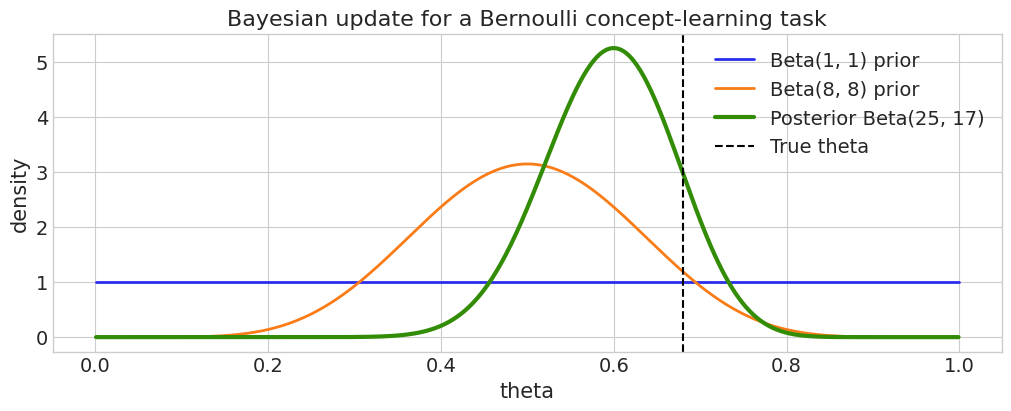

In [8]:
# Compare priors and posterior on a dense grid.
grid = np.linspace(0.001, 0.999, 500)

non_informative_prior = beta_dist.pdf(grid, 1, 1)
skeptical_prior = beta_dist.pdf(grid, 8, 8)
posterior_density = beta_dist.pdf(grid, posterior_a, posterior_b)

plt.figure(figsize=(10, 4))
plt.plot(grid, non_informative_prior, label="Beta(1, 1) prior", linewidth=2)
plt.plot(grid, skeptical_prior, label="Beta(8, 8) prior", linewidth=2)
plt.plot(grid, posterior_density, label=f"Posterior Beta({posterior_a}, {posterior_b})", linewidth=3)
plt.axvline(true_theta, color="black", linestyle="--", label="True theta")
plt.xlabel("theta")
plt.ylabel("density")
plt.title("Bayesian update for a Bernoulli concept-learning task")
plt.legend();


### Interpreting the prior-posterior plot

This plot is where the Bayesian workflow becomes visually different from MLE.

- `Beta(1, 1)` is flat: before seeing data, all values of `theta` are equally plausible.
- `Beta(8, 8)` is skeptical around `0.5`: it encodes the belief that extreme values near `0` or `1` are less plausible before data arrive.
- The posterior combines prior information and data into one updated uncertainty distribution.

The point is not that one prior is automatically correct. The point is that priors are explicit, inspectable modeling choices. Students can criticize them, compare them, and see exactly how much they matter.

### Core exercises for Section 1

1. **Smaller sample exercise.** Duplicate the synthetic-data cell and change `size=40` to `size=10`. Compare how much wider the posterior becomes and whether the prior matters more.
2. **More skeptical prior.** Keep the data fixed but replace `prior_a, prior_b = 1, 1` with `8, 8`. How much do the posterior mean and `P(theta > 0.5 | data)` move?
3. **Different decision threshold.** Modify the tail-probability line so that it computes `P(theta > 0.7 | data)`. Is the evidence still strong enough for that stricter threshold?

**Optional extension.** Choose a prior with prior mean `0.8` and explain whether the posterior is still dominated by the data or visibly pulled toward the prior. (N.B. Quindi serve che a = 4b. Ci sono infinite soluzioni)
